# Model Training

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../data/cleaned_data.csv')

In [4]:
X = df.drop(columns=["target"])
y = df["target"]

In [5]:
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Baseline Model - Logistic Regression

In [7]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",LogisticRegression(max_iter=1000,class_weight="balanced"))
    ]
)

In [8]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
y_pred_log = logistic_pipeline.predict(X_test)

y_prob_log = logistic_pipeline.predict_proba(X_test)[:,-1]

### Evaluate Baseline Model

In [10]:
# ROC-AUC
roc_auc_log = roc_auc_score(
    y_test,
    y_prob_log
)

print("ROC-AUC:", roc_auc_log)

# PR-AUC
pr_auc_log = average_precision_score(
    y_test,
    y_prob_log
)

print("PR-AUC:", pr_auc_log)


ROC-AUC: 0.6458284616609459
PR-AUC: 0.19918433362055157


In [11]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.65     20354
   macro avg       0.55      0.61      0.52     20354
weighted avg       0.84      0.65      0.71     20354



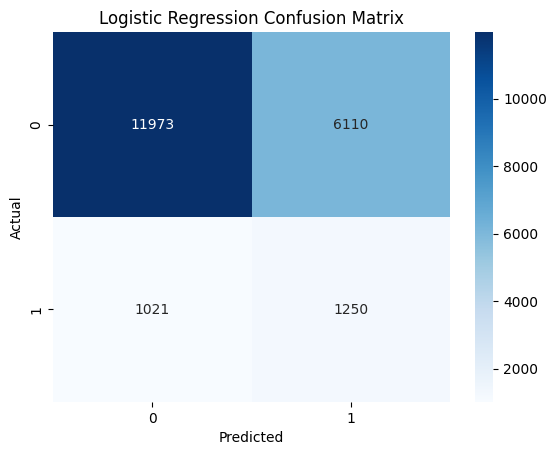

In [12]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_log
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Primary Model - XGBoost Model

In [13]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         XGBClassifier(
             objective="binary:logistic",
             eval_metric="logloss",
             random_state=42
         ))
    ]
)

In [14]:
# Define Hyperparamters Grid
param_grid = {

    "classifier__n_estimators": [100, 200],

    "classifier__max_depth": [3, 5, 7],

    "classifier__learning_rate": [0.01, 0.05, 0.1],

    "classifier__subsample": [0.8, 1.0],

    "classifier__colsample_bytree": [0.8, 1.0]
}

In [15]:
# Hyperparamter Tuning
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,

    param_distributions=param_grid,

    n_iter=10,

    scoring="roc_auc",

    cv=3,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

In [ ]:
random_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
best_model = random_search.best_estimator_

print(random_search.best_params_)

In [ ]:
y_pred_xgb = best_model.predict(X_test)

y_prob_xgb = best_model.predict_proba(X_test)[:, 1]

### Evaluate XGBoost

In [ ]:
# ROC-AUC
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("ROC-AUC:", roc_auc_xgb)

#PR-AUC
pr_auc_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

print("PR-AUC:", pr_auc_xgb)

In [ ]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Comparing Models

In [ ]:
comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],

    "ROC-AUC": [
        roc_auc_log,
        roc_auc_xgb
    ],

    "PR-AUC": [
        pr_auc_log,
        pr_auc_xgb
    ]
})

comparison_df

In [ ]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label="Logistic Regression"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label="XGBoost"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [ ]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

In [ ]:
comparison_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

## ** Important Observations **
## Logistic Regression
    1.Good baseline
    2.Interpretable
    3.Lower performance
## XGBoost
    1.Better nonlinear learning
    2.Higher ROC-AUC
    3.Better recall capability
    
## Why ROC-AUC Matters ?
 Because dataset is imbalanced.

## Why PR-AUC Matters ?
 Precision-recall is more informative for rare positive cases.

